Checking stationarity on the training data...
Augmented Dickey-Fuller Test:
ADF Statistic: -0.735143385344431
p-value: 0.8374354344380867
#Lags Used: 1
Number of Observations Used: 78
Weak evidence against the null hypothesis, series is non-stationary.
Consider differencing the data.

Checking stationarity on the differenced data...
Augmented Dickey-Fuller Test:
ADF Statistic: -11.770303623992753
p-value: 1.0939724287840997e-21
#Lags Used: 0
Number of Observations Used: 78
Strong evidence against the null hypothesis, series is stationary.

Plotting ACF and PACF for differenced data to find p and q...


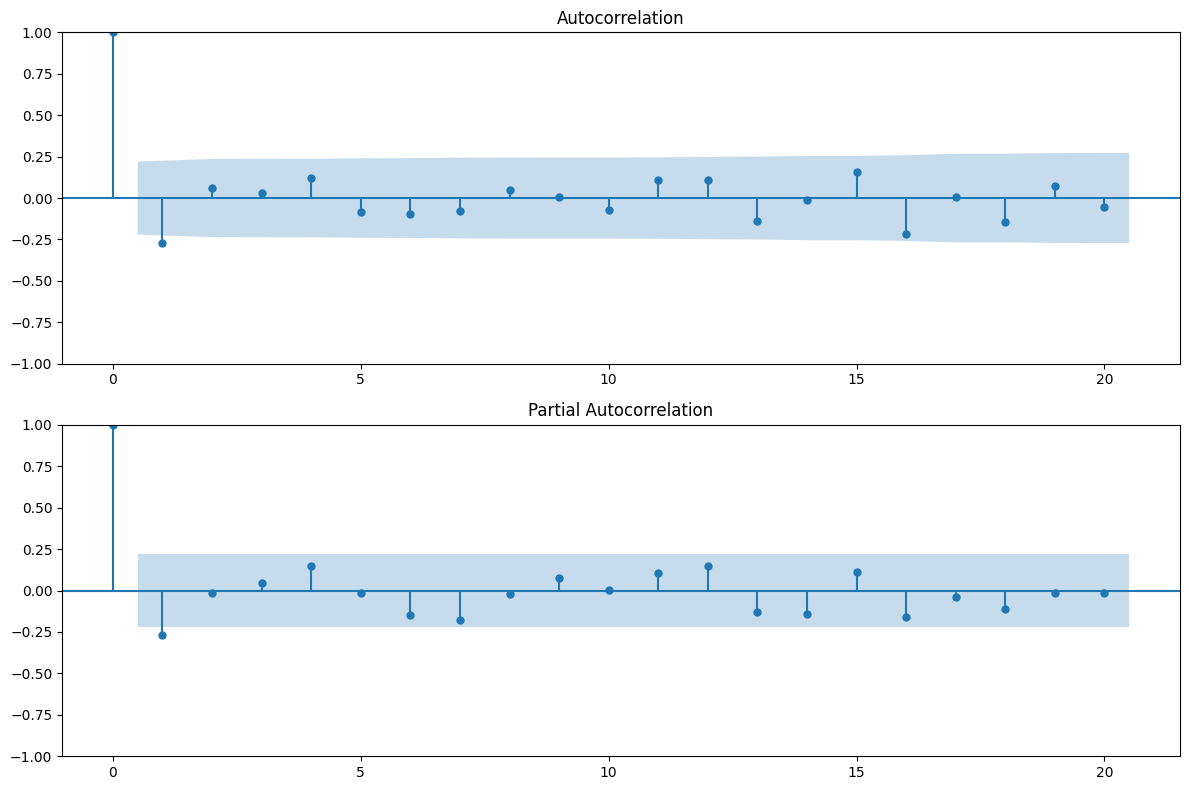


Fitting ARIMA(1, 1, 2) model...
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   80
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -109.700
Date:                Tue, 07 Oct 2025   AIC                            227.401
Time:                        18:28:21   BIC                            236.879
Sample:                    01-01-2020   HQIC                           231.198
                         - 03-20-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4428      0.355      1.247      0.213      -0.253       1.139
ma.L1         -0.7576      0.343     -2.210      0.027      -1.429      -0.086
ma.L2          0.31

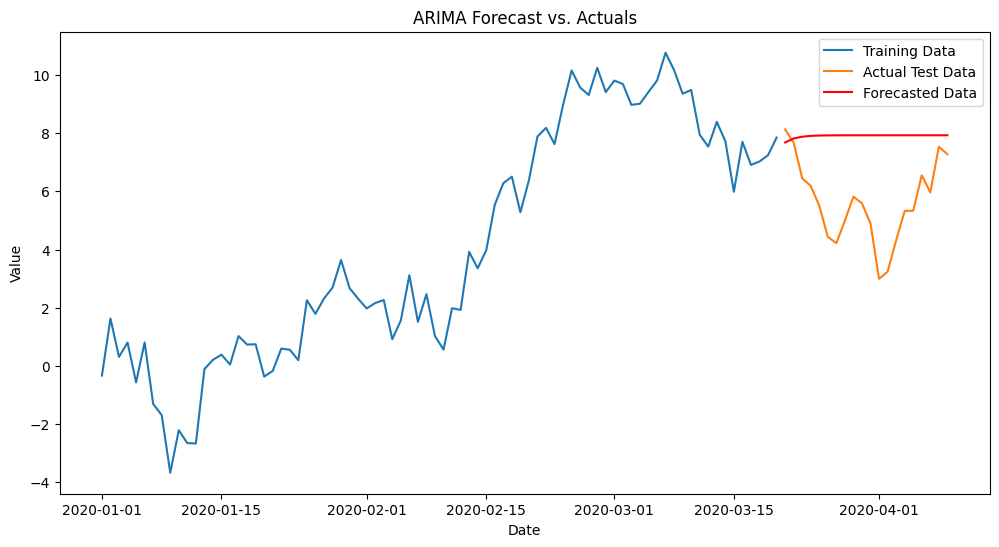

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
import numpy as np

# A sample dataset to demonstrate the ARIMA process
# In a real-world scenario, you would load your data from a file
# or database using pandas.
# Example: df = pd.read_csv('your_data.csv', parse_dates=['date_column'], index_col='date_column')
warnings.filterwarnings('ignore')
data = {
    'date': pd.date_range(start='2020-01-01', periods=100, freq='D'),
    'value': np.random.randn(100).cumsum() + np.linspace(0, 10, 100)
}
df = pd.DataFrame(data).set_index('date')


def check_stationarity(df_series):
    """
    Function to check the stationarity of a time series using the Augmented Dickey-Fuller test.
    
    Args:
        df_series (pd.Series): The time series to be tested.
    """
    result = adfuller(df_series.dropna())
    print("Augmented Dickey-Fuller Test:")
    labels = ['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label}: {value}')
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis, series is stationary.")
    else:
        print("Weak evidence against the null hypothesis, series is non-stationary.")
        print("Consider differencing the data.")


def plot_diagnostics(series, lags=20):
    """
    Function to plot the ACF and PACF to help determine ARIMA parameters.

    Args:
        series (pd.Series): The time series data.
        lags (int): The number of lags to plot.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(series.dropna(), ax=ax1, lags=lags)
    plot_pacf(series.dropna(), ax=ax2, lags=lags)
    plt.tight_layout()
    plt.show()


def fit_arima(train_series, order):
    """
    Fits an ARIMA model.
    
    Args:
        train_series (pd.Series): The training data.
        order (tuple): A tuple (p, d, q) for the ARIMA model.
        
    Returns:
        The fitted ARIMA model object.
    """
    model = ARIMA(train_series, order=order)
    model_fit = model.fit()
    return model_fit


def evaluate_arima_model(model_fit, test_series):
    """
    Generates predictions and evaluates the model performance using RMSE.
    
    Args:
        model_fit: The fitted ARIMA model object.
        test_series (pd.Series): The test data.
        
    Returns:
        tuple: A tuple containing the predictions and the RMSE.
    """
    start = len(model_fit.data.endog)
    end = start + len(test_series) - 1
    predictions = model_fit.predict(start=start, end=end, typ='levels')
    rmse = np.sqrt(mean_squared_error(test_series, predictions))
    return predictions, rmse


def visualize_forecast(train_series, test_series, predictions):
    """
    Plots the training data, actual test data, and predictions.
    
    Args:
        train_series (pd.Series): The training data.
        test_series (pd.Series): The actual test data.
        predictions (pd.Series): The predicted values.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(train_series.index, train_series, label='Training Data')
    plt.plot(test_series.index, test_series, label='Actual Test Data')
    plt.plot(predictions.index, predictions, color='red', label='Forecasted Data')
    plt.title('ARIMA Forecast vs. Actuals')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


def main():
    """
    Main function to run the time series analysis and forecasting process.
    """
    # Step 1: Data Preparation
    # Split the data into training and testing sets
    train_size = int(len(df) * 0.8)
    train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

    # Step 2: Check for Stationarity
    print("Checking stationarity on the training data...")
    check_stationarity(train_data['value'])

    # Step 3: Determine ARIMA parameters (p, d, q)
    # If the series is non-stationary (high p-value), apply differencing.
    # In this example, with a random walk trend, differencing is needed.
    df_diff = train_data['value'].diff().dropna()
    print("\nChecking stationarity on the differenced data...")
    check_stationarity(df_diff)

    print("\nPlotting ACF and PACF for differenced data to find p and q...")
    plot_diagnostics(df_diff)
    
    # Based on the ACF and PACF plots, select the p and q parameters.
    # For this example, we'll use a placeholder order (1, 1, 1).
    # In practice, you would interpret the plots to determine the appropriate p and q.
    # d is 1 because we applied a single differencing step.
    p, d, q = 1,1,2

    # Step 4: Fit the ARIMA model
    print(f"\nFitting ARIMA({p}, {d}, {q}) model...")
    model_fit = fit_arima(train_data['value'], order=(p, d, q))
    print(model_fit.summary())

    # Step 5: Evaluate Model Performance and Forecast
    print("\nEvaluating model performance...")
    predictions, rmse = evaluate_arima_model(model_fit, test_data['value'])
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    # Step 6: Visualize the Forecast
    print("\nVisualizing the forecast...")
    visualize_forecast(train_data['value'], test_data['value'], predictions)


if __name__ == "__main__":
    main()

